In [1]:
import pandas as pd
print("version: 1.0.1")

version: 1.0.1


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhbagchi/books-dataset")

print("Path to dataset files:", path)

c:\Users\Shaked\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


?Path to dataset files: C:\Users\Shaked\.cache\kagglehub\datasets\saurabhbagchi\books-dataset\versions\1


In [3]:
import pandas as pd

df = pd.read_csv(
    path + r"\books_data\Ratings.csv",
    encoding="latin-1",
    sep=";",
    engine="python",
    on_bad_lines="warn"
)

print(df.shape)

books = pd.read_csv(
    path + r"\books_data\Books.csv",
    encoding="latin-1",
    sep=";",
    engine="python",
    on_bad_lines="warn"
)
df.head()

user = pd.read_csv(
    path + r"\books_data\Users.csv",
    encoding="latin-1",
    sep=";",
    engine="python",
    on_bad_lines="warn"
)


Skipping line 21689: ';' expected after '"'
Skipping line 45329: ';' expected after '"'
Skipping line 45330: ';' expected after '"'
Skipping line 183262: ';' expected after '"'
Skipping line 210093: ';' expected after '"'
Skipping line 531938: ';' expected after '"'
Skipping line 663237: ';' expected after '"'
Skipping line 824822: ';' expected after '"'
Skipping line 877349: ';' expected after '"'
Skipping line 941679: ';' expected after '"'
Skipping line 1134132: ';' expected after '"'
Skipping line 1145176: ';' expected after '"'
Skipping line 1145177: ';' expected after '"'
Skipping line 1148551: ';' expected after '"'


(1149766, 3)


Skipping line 815: ';' expected after '"'
Skipping line 1679: ';' expected after '"'
Skipping line 2531: ';' expected after '"'
Skipping line 2640: ';' expected after '"'
Skipping line 3236: ';' expected after '"'
Skipping line 3256: ';' expected after '"'
Skipping line 4906: ';' expected after '"'
Skipping line 6452: ';' expected after '"'
Skipping line 8349: ';' expected after '"'
Skipping line 9669: ';' expected after '"'
Skipping line 9723: ';' expected after '"'
Skipping line 10010: ';' expected after '"'
Skipping line 10192: ';' expected after '"'
Skipping line 10754: ';' expected after '"'
Skipping line 10824: ';' expected after '"'
Skipping line 10862: ';' expected after '"'
Skipping line 11442: ';' expected after '"'
Skipping line 11584: ';' expected after '"'
Skipping line 11859: ';' expected after '"'
Skipping line 12206: ';' expected after '"'
Skipping line 12229: ';' expected after '"'
Skipping line 12719: ';' expected after '"'
Skipping line 12885: ';' expected after '"'


In [4]:
len(books)
books['ISBN'].nunique()
# books['ISBN'].isna().sum() 0
# books['ISBN'].duplicated().sum() 0 
books['ISBN'].dtype
books.head()








,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
df.head()
# df['ISBN'].isna().sum() 0
df['ISBN'].dtype

df.groupby('ISBN').size().sort_values(ascending=False).head(10)
# df['Book-Rating'].apply(type).value_counts() everything 1149766 is int

top_books = (
    df.groupby('ISBN')['Book-Rating']
      .agg(['size', 'mean'])
      .sort_values('size', ascending=False)
      .head(10)
)
top_books = top_books.reset_index()

top_books






,ISBN,size,mean
0,0971880107,2502,1.019584
1,0316666343,1295,4.468726
2,0385504209,883,4.652322
3,0060928336,732,3.448087
4,0312195516,723,4.334716
5,044023722X,647,3.187017
6,0679781587,639,4.381847
7,0142001740,615,4.219512
8,067976402X,614,3.255700
9,0671027360,586,3.718430


In [6]:

top_books_with_info_1a = books.merge(
    top_books,
    on="ISBN",
    how="left"
)
top_books_with_info_1a

isbn = books["ISBN"].iloc[0]

print(repr(isbn))
print(top_books["ISBN"].head())
print(isbn in top_books["ISBN"].values)





'0195153448'
0    0971880107
1    0316666343
2    0385504209
3    0060928336
4    0312195516
Name: ISBN, dtype: object
False


In [40]:
book_stats = df.groupby("ISBN")["Book-Rating"].agg(
    size="size",
    mean="mean"
).reset_index()
book_stats


top_books_with_info = books.merge(
    book_stats,
    on="ISBN",
    how="left"
)

top_books_with_info[["size", "mean"]] = (
    top_books_with_info[["size", "mean"]].fillna(0)
)

features = [
    "Book-Author",
    "Year-Of-Publication",
    "Publisher",
    "size",
    "mean"
    
]
X = top_books_with_info[features]
X = X[X["Year-Of-Publication"] < 2027]




In [41]:
from sklearn.model_selection import train_test_split

y = X["mean"]
X = X[["Year-Of-Publication", "size"]]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
p = model.predict(X_test)
mse = mean_squared_error(y_test, p)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 10.5631


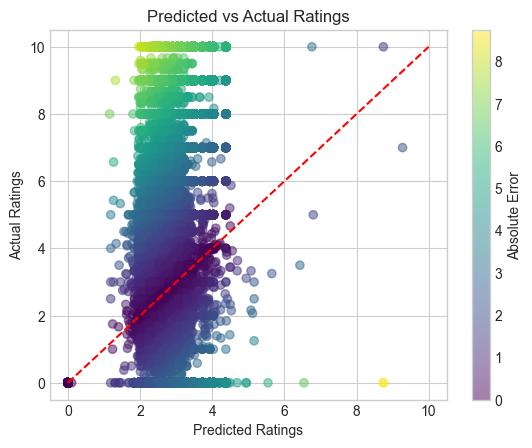

<Figure size 1000x600 with 0 Axes>

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# plt.style.use("seaborn-v0_8-whitegrid")

plt.scatter(p, y_test, alpha=0.5, c=abs(p-y_test), cmap='viridis')

plt.title("Predicted vs Actual Ratings")
plt.xlabel("Predicted Ratings")
plt.ylabel("Actual Ratings")

min_val = min(min(p), min(y_test))
max_val = max(max(p), max(y_test))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

cbar = plt.colorbar()
cbar.set_label("Absolute Error")

fig = plt.figure(figsize=(10, 6), facecolor='whitesmoke')
# fig = plt.figure(figsize=(100, 60))

In [31]:
print(p)
print(y_test)

[1. 1. 2. ... 3. 2. 1.]
172587    1.0
218274    1.0
71549     2.0
220850    4.0
205987    1.0
         ... 
224212    1.0
254040    1.0
80301     3.0
213038    2.0
234769    1.0
Name: size, Length: 54096, dtype: float64


In [ ]:
# handle non values
